# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you would be able to present to future employers. One is a brief one-page summary of this project that you would present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Please consider your prior course work and select one way to achieve this given project question. Either use a regression model or machine learning model to predict whether or not an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


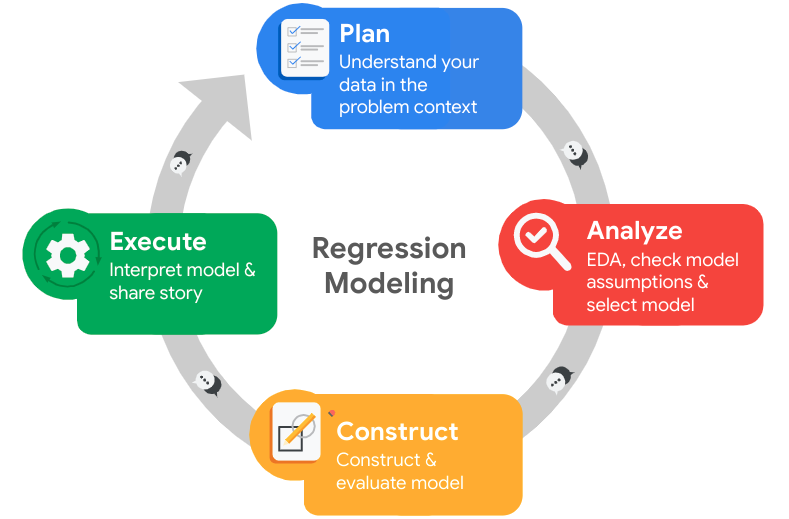

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




Stakeholders: Saliford Motors. 
Predict Employee churn.
Need to confirm if satifaction level is binary or continous variable for regression model. Its a float.
Jupyter notebooks/data
Ethical considerations. Confidentiality of data. Employees maybe identifiable by salient attributes.

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [56]:
# Import packages
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
import sklearn.metrics as metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve

#from sklearn.metricsfrom sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
#pd.set_option('display.max_columns', None)

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [7]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
df0.head(5)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [3]:
# Gather basic information about the data
df0.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [4]:
# Gather descriptive statistics about the data
df0.describe()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
# Display all column names
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [8]:
# Rename columns as needed
df0.rename(columns={'Work_accident': 'work_accident', 'Department': 'department', 'time_spend_company': 'tenure', 'average_montly_hours': 'average_monthly_hours'}, inplace=True)


# Display all column names after the update
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [9]:
# Check for missing values
df0.isnull().sum()


satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [8]:
# Check for duplicates
#pd.options.display.max_colwidth = 10
df0.duplicated().sum()
#



3008

In [12]:
# Inspect some rows containing duplicates as needed
mask = df0.duplicated(keep=False)
#print(df0[mask])



In [11]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df = df0.drop_duplicates()


# Display first few rows of new dataframe as needed
df.head(5)
df['tenure'].value_counts()

tenure
3     5190
2     2910
4     2005
5     1062
6      542
10     107
7       94
8       81
Name: count, dtype: int64

### Check outliers

Check for outliers in the data.

Text(0.5, 0, 'Numer of Year Employed')

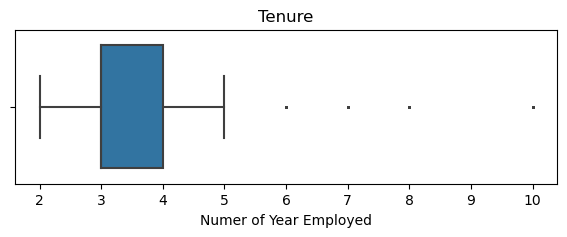

In [14]:
# Create a boxplot to visualize distribution of `tenure` and detect any outliers


plt.figure(figsize=(7,2))#
plt.title('Tenure')
g = sns.boxplot(data=df, x=df['tenure'], fliersize=1);
g.set_xlabel('Numer of Year Employed')
#g.set_ylabel('Sales ($)')


In [12]:
# Determine the number of rows containing outliers
mean = np.mean(df['tenure'])
percentile25 = df0['tenure'].quantile(0.25)
percentile75 = df0['tenure'].quantile(0.75)

iqr = percentile75 - percentile25
lower_limit = percentile25 - 1.5 * iqr
upper_limit = percentile75 + 1.5 * iqr

out_mask = (df['tenure'] > upper_limit) | (df['tenure'] < lower_limit)
outliers = df[out_mask]
print(lower_limit)
print(upper_limit)
#df['tenure'].value_counts()

def tenure(tenure): 
    if (tenure > upper_limit):
        return upper_limit
    elif (tenure < lower_limit): 
        return lower_limit
    else:
        return tenure

df.loc[:, 'tenure']  = df.loc[:, 'tenure'].apply(tenure)


1.5
5.5


In [13]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.273455,0.154282,0.166041,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.057809,0.361234,0.372133,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,5.500000,1.000000,1.000000,1.000000


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [15]:
# Get numbers of people who left vs. stayed
#df.columns
#df['left'].value_counts()

df['left'].value_counts(normalize=True)

# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

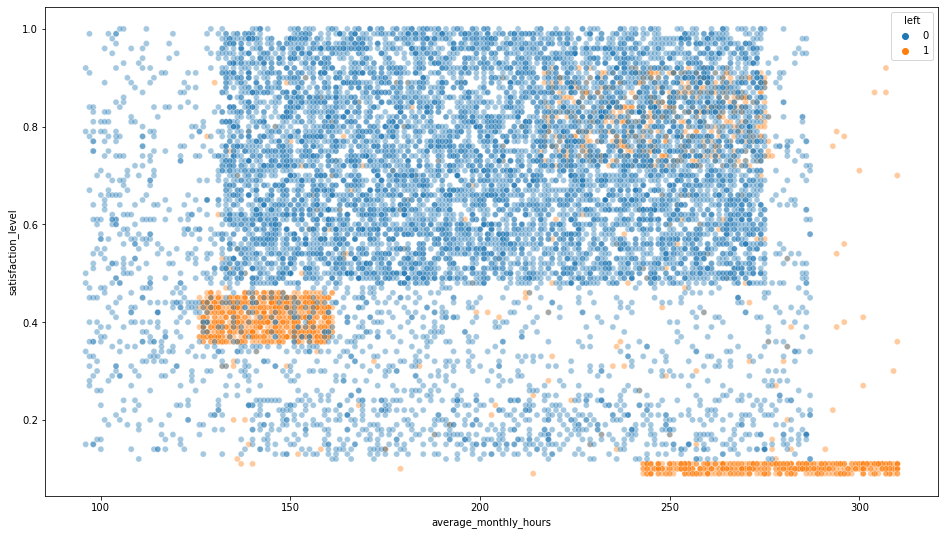

In [55]:
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.show()
#not correlated

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

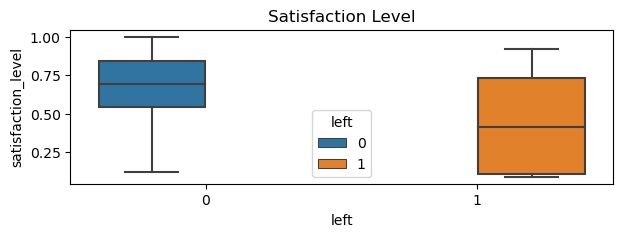

In [18]:
# Create a plot as needed
#
plt.figure(figsize=(7,2))#
plt.title('Satisfaction Level')
sns.boxplot(data=df, y=df['satisfaction_level'], x= df['left'], hue=df['left'], fliersize=1);

df.columns


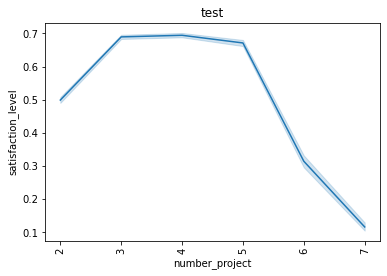

In [196]:
# Create histogram of total_amount
g = sns.lineplot(
    data = df,
    x = 'number_project',
    y = 'satisfaction_level',
    #  multiple='dodge',
  # shrink=5,
  #  hue = 'left');
);
g.set_title('test');
plt.xticks(rotation=90)
plt.show()



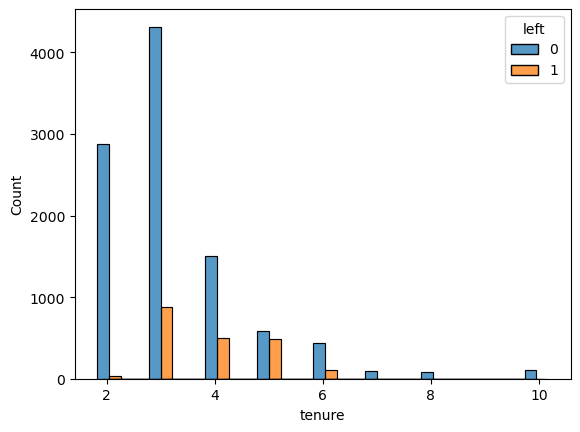

In [19]:
g = sns.histplot(
    data = df,
    x = 'tenure',
#    y = 'left',
     multiple='dodge',
    shrink=5,
    hue = 'left');


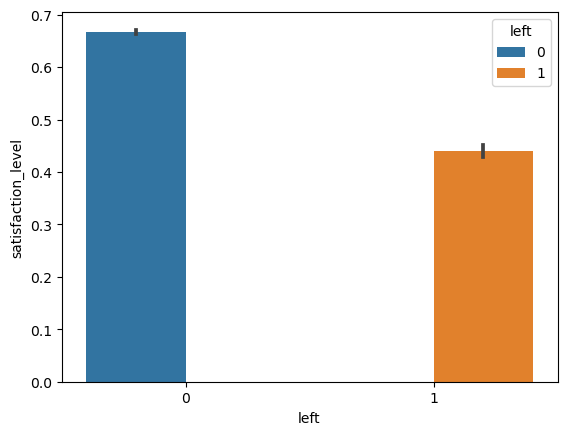

In [20]:
g = sns.barplot(
    data = df,
     x = 'left',
     y = 'satisfaction_level',
   #  multiple='dodge',
   # bins = 100,
  #  shrink=5,
    hue = 'left');


In [219]:
df.groupby(df['left']).mean()
df.groupby(df['left']).median()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,promotion_last_5years
left,,,,,,,
0,0.69,0.71,4.0,198.0,3.0,0.0,0.0
1,0.41,0.79,4.0,226.0,4.0,0.0,0.0


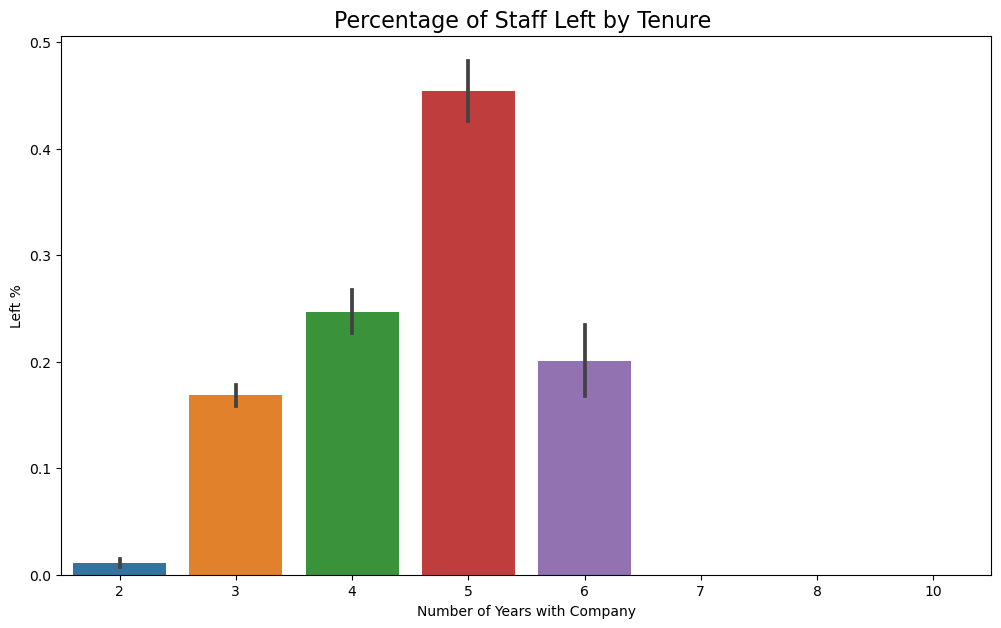

In [22]:
# Create a plot as needed
# Create bar plot for ride count by day
plt.figure(figsize=(12,7))
ax = sns.barplot(x=df['tenure'], y=df['left'])
#ax.set_xticklabels(day_order)
ax.set_ylabel('Left %')
ax.set_xlabel('Number of Years with Company')
plt.title('Percentage of Staff Left by Tenure ', fontsize=16);


In [18]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

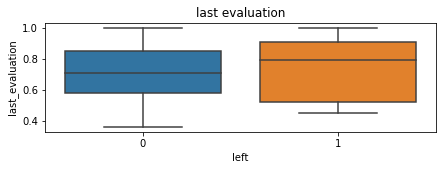

In [19]:
# Create a plot as needed
#
plt.figure(figsize=(7,2))#
plt.title('last evaluation')
sns.boxplot(data=df, y=df['last_evaluation'], x= df['left'], fliersize=1);



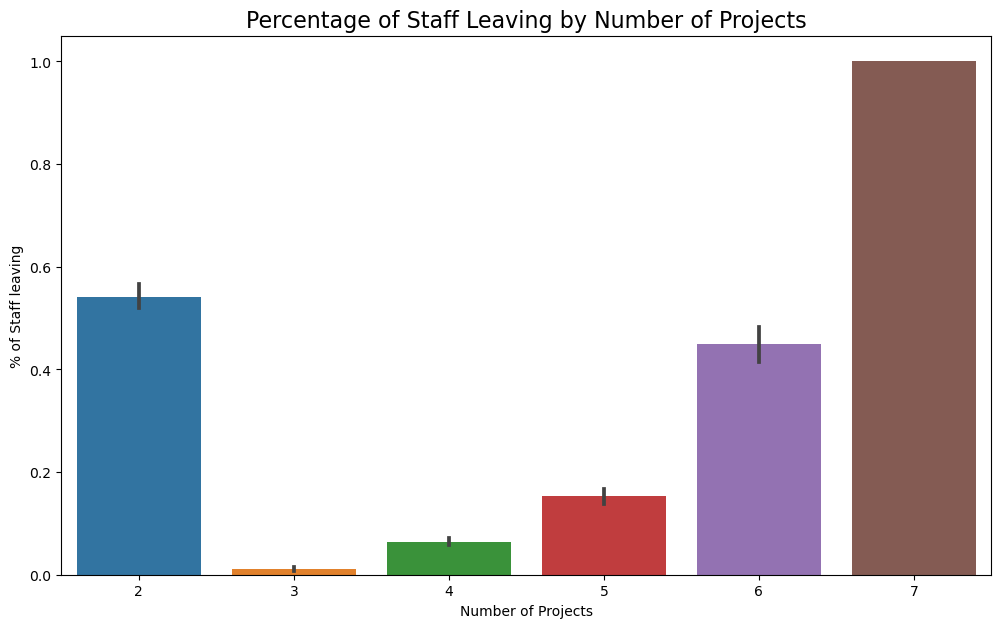

In [31]:
# Create a plot as needed
plt.figure(figsize=(12,7))
ax = sns.barplot(x=df['number_project'], y=df['left'])
#ax.set_xticklabels(day_order)
ax.set_ylabel('% of Staff leaving')
ax.set_xlabel('Number of Projects')
plt.title('Percentage of Staff Leaving by Number of Projects', fontsize=16);


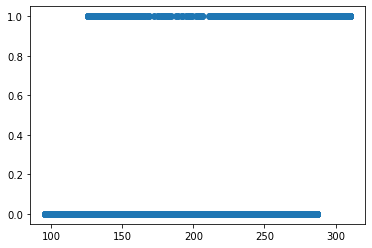

In [21]:
x = df['average_monthly_hours']
y = df['left']
plt.scatter(x, y)
plt.show()


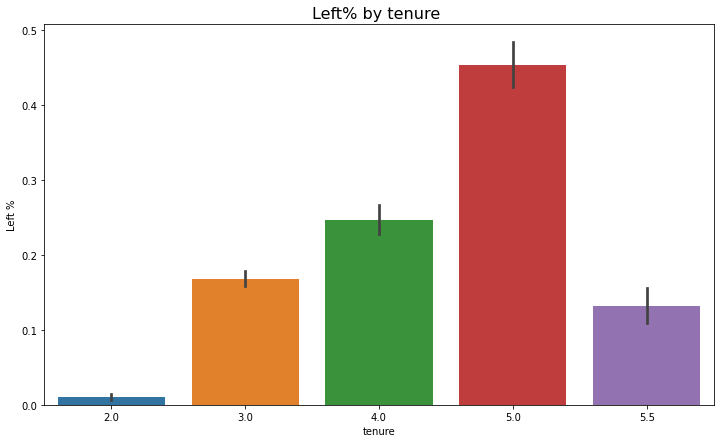

In [22]:
# Create a plot as needed
# Create bar plot for ride count by day
plt.figure(figsize=(12,7))
ax = sns.barplot(x=df['tenure'], y=df['left'])
#ax.set_xticklabels(day_order)
ax.set_ylabel('Left %')
plt.title('Left% by tenure ', fontsize=16);


In [23]:
# Create a plot as needed
df['work_accident'].value_counts()

0    10141
1     1850
Name: work_accident, dtype: int64

In [24]:
# Create a plot as needed
mask = (df['work_accident'] == 1)
a = df[mask]
a = a[['work_accident', 'left']].value_counts(normalize=True)
mask2 = (df['work_accident'] == 0)
b = df[mask2]
b = b[['work_accident', 'left']].value_counts(normalize=True)
print(a)
print(b)
df.columns

work_accident  left
1              0       0.943243
               1       0.056757
dtype: float64
work_accident  left
0              0       0.814022
               1       0.185978
dtype: float64


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

In [25]:
mask = (df['promotion_last_5years'] == 1)
a = df[mask]
a = a[['promotion_last_5years', 'left']].value_counts(normalize=True)
mask2 = (df['promotion_last_5years'] == 0)
b = df[mask2]
b = b[['promotion_last_5years', 'left']].value_counts(normalize=True)
print(a)
print(b)
df.columns

promotion_last_5years  left
1                      0       0.960591
                       1       0.039409
dtype: float64
promotion_last_5years  left
0                      0       0.831778
                       1       0.168222
dtype: float64


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

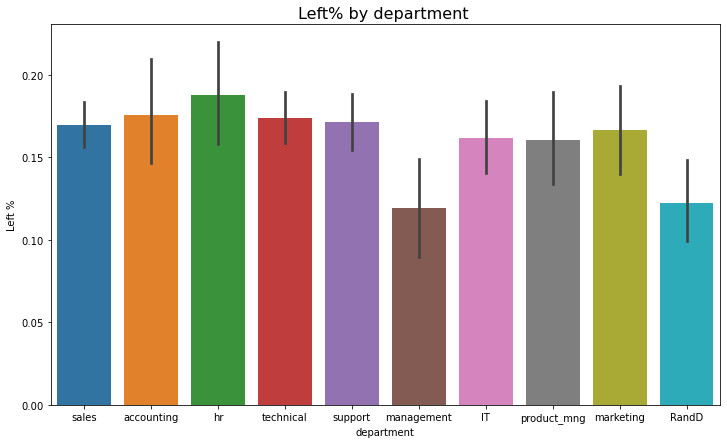

In [26]:
# Create a plot as needed
# Create bar plot for ride count by day
plt.figure(figsize=(12,7))
ax = sns.barplot(x=df['department'], y=df['left'])
#ax.set_xticklabels(day_order)
ax.set_ylabel('Left %')
plt.title('Left% by department ', fontsize=16);

df.columns

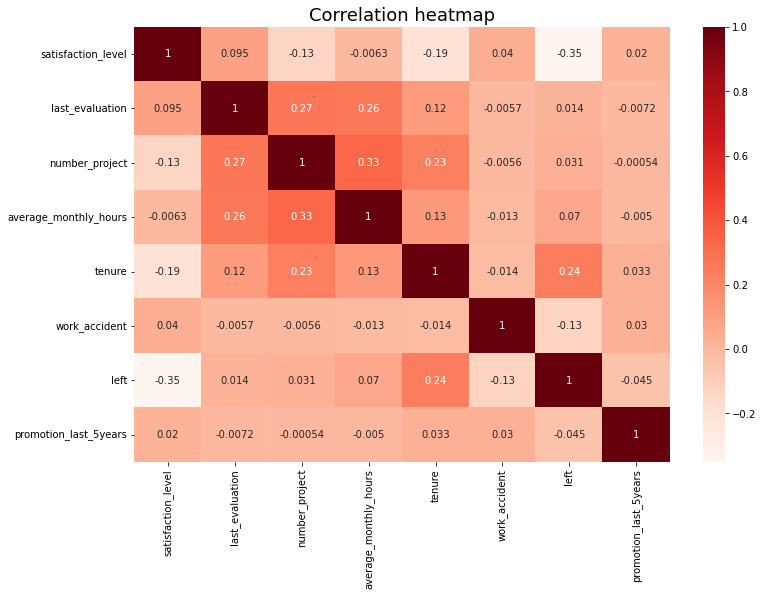

In [27]:
# Create correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(method='pearson'), annot=True, cmap='Reds')
plt.title('Correlation heatmap',
          fontsize=18)
plt.show()


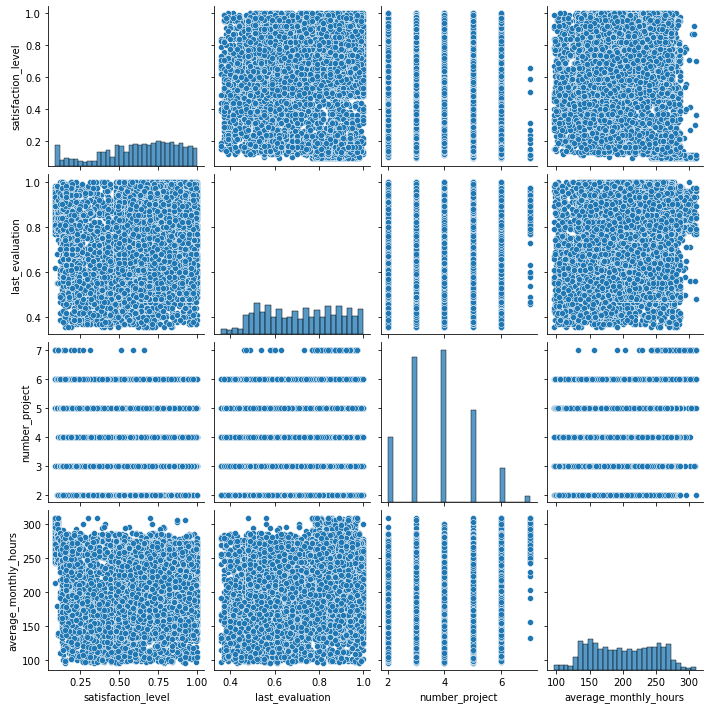

In [43]:
pp = sns.pairplot(
    df,
    x_vars=["satisfaction_level", "last_evaluation", "number_project", "average_monthly_hours"],
    y_vars=["satisfaction_level", "last_evaluation", "number_project", "average_monthly_hours"],
)


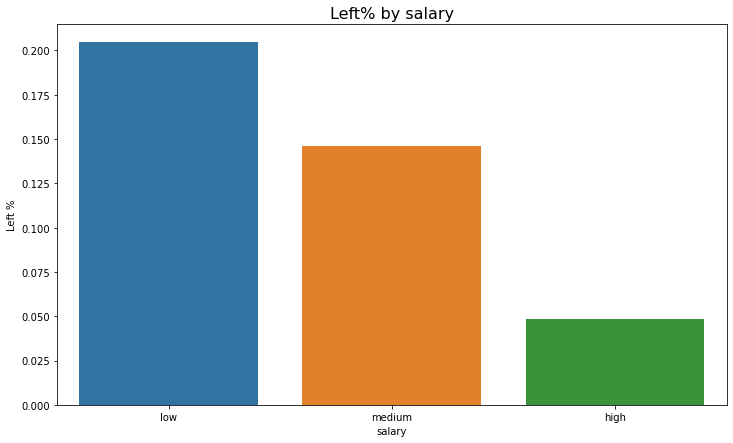

In [28]:
# Create a plot as needed
#
plt.figure(figsize=(12,7))
ax = sns.barplot(x=df['salary'], y=df['left'], ci=None)
#ax.set_xticklabels(day_order)
ax.set_ylabel('Left %')
plt.title('Left% by salary', fontsize=16);


In [33]:

df2 = pd.get_dummies(df, drop_first=False)


In [30]:
df2.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department_IT,department_RandD,...,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3.0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,0.80,0.86,5,262,5.5,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.11,0.88,7,272,4.0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,0.72,0.87,5,223,5.0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,0.37,0.52,2,159,3.0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0


## Logistic Regression Model

### Create the X (features) and y (dependent variable) in randomized splits

In [50]:
X = df2[['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours',  'work_accident', 'department_IT', 
       'department_RandD',  'department_accounting', 'department_hr', 'department_management',
       'department_marketing', 'department_product_mng'
        
       ]]
y = df2[["left"]]

# Split dataset into training and holdout datasets
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)
#y_train.info()

In [51]:
%%time
# Initialize logistic regression classifier
clf = LogisticRegression()

# Fit your model to the training data
clf = LogisticRegression().fit(X_train, y_train)


CPU times: total: 31.2 ms
Wall time: 78.1 ms


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [52]:
# Print the coefficient
clf.coef_

array([[-3.98968385,  0.84988991, -0.2054669 ,  0.00418402, -1.2329689 ,
        -0.07113374, -0.47206512, -0.08382682,  0.0975081 , -0.39759446,
         0.06850006,  0.00455995]])

In [53]:
# Print the intercept
clf.intercept_

array([0.10401592])

In [54]:
#get predictions on the X test
y_pred = clf.predict(X_test)

In [57]:
print("Accuracy:", "%.6f" % metrics.accuracy_score(y_test, y_pred))
print("Precision:", "%.6f" % metrics.precision_score(y_test, y_pred))
print("Recall:", "%.6f" % metrics.recall_score(y_test, y_pred))
print("F1 Score:", "%.6f" % metrics.f1_score(y_test, y_pred))


Accuracy: 0.852902
Precision: 0.689189
Recall: 0.205231
F1 Score: 0.316279


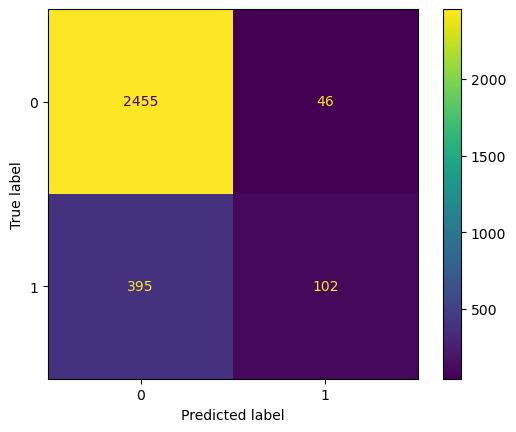

In [58]:
#Confusion Matrix
# Calculate the values for each quadrant in the confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred, labels = clf.classes_)

# Create the confusion matrix as a visualization
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = clf.classes_)

# Display the confusion matrix
disp.plot()


In [59]:
# Create classification report for logistic regression model
target_names = ['Predicted would not leave', 'Predicted would leave']
print(classification_report(y_test, y_pred, target_names=target_names))


                           precision    recall  f1-score   support

Predicted would not leave       0.86      0.98      0.92      2501
    Predicted would leave       0.69      0.21      0.32       497

                 accuracy                           0.85      2998
                macro avg       0.78      0.59      0.62      2998
             weighted avg       0.83      0.85      0.82      2998



In [39]:
X.describe()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,work_accident,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,0.154282,0.081394,0.057877,0.051789,0.050121,0.036361,0.056125,0.057210
std,0.241070,0.168343,1.163238,48.727813,0.361234,0.273451,0.233520,0.221610,0.218204,0.187194,0.230173,0.232252
min,0.090000,0.360000,2.000000,96.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Random Forests

In [109]:
#Feature Engineering

df2.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department_IT', 'department_RandD',
       'department_accounting', 'department_hr', 'department_management',
       'department_marketing', 'department_product_mng', 'department_sales',
       'department_support', 'department_technical', 'salary_high',
       'salary_low', 'salary_medium'],
      dtype='object')

## Random Forest Model

In [65]:
rf = RandomForestClassifier(random_state=0)

cv_params = {'max_depth': [2,3,4,5, None],  #None means that one tree can grow without limit
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'max_features': [2,3,4],
             'n_estimators': [75, 100, 125, 150]
             }  

scoring = {'accuracy', 'precision', 'recall', 'f1'}

rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='f1')


In [67]:
%%time
rf_cv.fit(X_train, y_train)


CPU times: user 14min 49s, sys: 2.62 s, total: 14min 52s
Wall time: 14min 52s


GridSearchCV(cv=5, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_jobs=None,
                                              oob_score=False, random_state=0,
                                   

In [111]:
path = '/home/jovyan/work/'

In [113]:
# Pickle the model  - view lab files to confirm its pickled.
import pickle
with open(path+'rf_course7.pickle', 'wb') as to_write:
    pickle.dump(rf_cv, to_write)

In [68]:
# Examine best score: This is the value used in refit='f1' # so here we are using f1 on the GridSearch Parameter
rf_cv.best_score_

0.8885218164284356

In [69]:
# Examine best parameters
rf_cv.best_params_

{'max_depth': None,
 'max_features': 4,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 125}

In [88]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
    model_name (string): what you want the model to be called in the output table
    model_object: a fit GridSearchCV object
    metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                 'recall': 'mean_test_recall',
                 'f1': 'mean_test_f1',
                 'accuracy': 'mean_test_accuracy',
                 }
    cv_results = pd.DataFrame(model_object.cv_results_)
        # Isolate the row of the df with the max(mean f1 score)
    best_estimator_results = cv_results.iloc[cv_results['mean_test_f1'].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
  
    # Create table of results
    table = pd.DataFrame({'Model': [model_name],
                        'F1': [f1],
                        'Recall': [recall],
                        'Precision': [precision],
                        'Accuracy': [accuracy]
                         }
                        )
  
    return table


In [90]:
# Call 'make_results()' on the GridSearch object
rf_cv_results = make_results('Random Forests', rf_cv, 'f1')
rf_cv_results

,Model,F1,Recall,Precision,Accuracy
0,Random Forests,0.888522,0.859426,0.919931,0.964195


In [91]:
# Get scores on test data
rf_cv_preds = rf_cv.predict(X_test)

In [92]:
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Generate a table of test scores.

    In:
    model_name (string): Your choice: how the model will be named in the output table
    preds: numpy array of test predictions
    y_test_data: numpy array of y_test data

    Out:
    table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                        'precision': [precision],
                        'recall': [recall],
                        'F1': [f1],
                        'accuracy': [accuracy]
                        })

    return table

In [108]:
 # Get scores on test data
g = get_test_scores("test results", rf_cv_preds, y_test) #prediction results
m = make_results('Random Forests best results', rf_cv, 'f1')  #best results

results = pd.concat([g, m], axis=0)
print(g)
print(m)


          model  precision    recall        F1  accuracy
0  test results   0.901261  0.863179  0.881809  0.961641
                         Model        F1    Recall  Precision  Accuracy
0  Random Forests best results  0.888522  0.859426   0.919931  0.964195


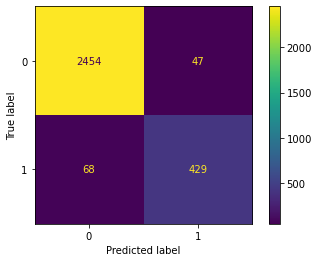

In [126]:
#Confusion Matrix
# Calculate the values for each quadrant in the confusion matrix
cm = metrics.confusion_matrix(y_test, rf_cv_preds, labels = rf_cv.classes_)


# Create the confusion matrix as a visualization
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = rf_cv.classes_)


#fig, ax = plt.subplots(figsize=(5, 5))  # Adjust the figure size if necessary
        
# Display the confusion matrix
disp.plot(values_format="d")


In [128]:
# Create classification report for logistic regression model
target_names = ['Predicted would not leave', 'Predicted would leave']
print(classification_report(y_test, rf_cv_preds, target_names=target_names))


                           precision    recall  f1-score   support

Predicted would not leave       0.97      0.98      0.98      2501
    Predicted would leave       0.90      0.86      0.88       497

                 accuracy                           0.96      2998
                macro avg       0.94      0.92      0.93      2998
             weighted avg       0.96      0.96      0.96      2998



### Insights

satisfaction level - very good predictor
#last_evaluation- not a good predcitor
#number_project - good predictor
#average_monthly_hours - minor preditor
#tenure - good predictor
#work_accident  - exclude
#promotion_lat_year good predictor
#department minor predictor
#salary = reasonable predictor

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



[Double-click to enter your responses here.]

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

[Double-click to enter your responses here.]

### Identify the types of models most appropriate for this task.

[Double-click to enter your responses here.]

### Modeling

Add as many cells as you need to conduct the modeling process.

In [40]:
#X = activity[[""]]
#y = activity[["LyingDown"]]
# Split dataset into training and holdout datasets
#X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



Double-click to enter your responses here.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

[Double-click to enter your summary here.]

### Conclusion, Recommendations, Next Steps

[Double-click to enter your conclusion, recommendations, and next steps here.]

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.